---
title: 'Solutions: Evaluating Machine Learning Models'
author: Mark Fuge
format:
    html:
        code-fold: true
        code-summary: "Show Solution Code"
---

Worked solutions to the exercises at the end of the chapter *Evaluating Machine Learning Models*.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from scipy.spatial.distance import cdist
from scipy.stats import chi, loguniform, randint, uniform
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, GroupKFold, KFold, ShuffleSplit, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, PolynomialFeatures, StandardScaler

warnings.simplefilter('ignore', RuntimeWarning)

# The chapter's cos data (same seed as the chapter)
np.random.seed(1)
n_samples = 30
true_fun = lambda X: np.cos(1.5 * np.pi * X)
X_cos = np.sort(np.random.rand(n_samples))
y_cos = true_fun(X_cos) + np.random.randn(n_samples) * 0.1
X_cos = X_cos[:, np.newaxis]

### Exercise 1: Which split would you use?

| Situation | Strategy | Grouped or stratified on | Leakage a shuffled split would cause |
|---|---|---|---|
| (a) Bridge strain gauge, predict one hour ahead | Time series split | time | The model would train on readings from *after* the ones it is tested on, which does not match reality and would make the model overly optimistic. |
| (b) Six blades, 30 scans each, new blades in deployment | Group K-fold | blade | Thirty scans of the same blade end up on both sides of the split. If we don't group them for cross validation the model can easily memorize each blade rather than learning what generalizes to a new one. |
| (c) Weld images, 2 percent defective | Stratified K-fold | defect label | A random fold can contain zero defects, which makes precision and recall undefined and the fold's score meaningless. With so few positives you also want them spread evenly across both training and test. |
| (d) Forty independently cast and tested specimens | Shuffled K-fold (or shuffle split) | nothing | None: the rows are independent draws, which is exactly what shuffled K-fold assumes. Leave-one-out CV is also reasonable with only forty rows. |
| (e) Four plants, with a new machine at a fifth | Group K-fold | plant | Lighting, cameras and welding procedures differ by plant; mixing plants across the split lets the model learn plant-specific quirks that will not exist at the fifth plant. Holding out entire plants (leave-one-plant-out with four groups) would more closely mirror reality. |
| (f) Twenty cells, forecast the remaining life of *these* cells | Time series split within each cell | time (per cell) | The future of each cell would leak into its past. Since the deployment target is the same cells, grouping by cell would answer the wrong question; the honest split trains on the early cycles and tests on the later ones. |

The last two are the instructive ones: (e) and (f) look similar (several units, many rows each) but the deployment question differs, and the deployment question decides the split.

### Exercise 2: Read the validation curve

In [3]:
alphas_1d = np.logspace(start=-13, stop=4, num=20)
polynomial_features = PolynomialFeatures(degree=15, include_bias=False)
scores_1d = []
for a in alphas_1d:
    pipeline = Pipeline([("polynomial_features", polynomial_features), ("linear_regression", Ridge(alpha=a))])
    scores_1d.append(cross_val_score(pipeline, X_cos, y_cos, scoring="neg_mean_squared_error", cv=20))
scores_1d = np.array(scores_1d)
mean_mse_1d = -scores_1d.mean(axis=1)
best = np.argmin(mean_mse_1d)
print(f"lowest CV MSE {mean_mse_1d[best]:.4f} at alpha = {alphas_1d[best]:.2e}")

lowest CV MSE 0.0201 at alpha = 5.46e-03


**(a)** The minimum sits at $\alpha \approx 10^{-3}$ (the exact value is printed above).

**(b)** At the right end the penalty dominates: the weights are shrunk towards zero, the 15-degree polynomial degenerates into a nearly flat line and cannot follow the cosine. That is *bias*: the model is too simple for the data no matter how the sample is drawn. At the left end the penalty is gone and the 15-degree polynomial fits the 24 training points of each fold essentially exactly, including their noise. Small changes in which points land in the training fold produce wildly different curves between the points. That is *variance*: the model is too flexible for thirty noisy points.

**(c)** The columns of a 15-degree polynomial design matrix on $[0, 1]$ are almost linearly dependent ($x^{14}$ and $x^{15}$ look nearly the same), so the unregularized least-squares problem is close to singular: a few directions in weight space change the fit hardly at all, and the solver puts enormous coefficients into them (the previous chapter printed weights in the thousands and millions). Ridge adds $\alpha$ to the curvature of every direction. For the nearly flat directions even $\alpha = 10^{-9}$ is *large* compared with their own curvature, so it collapses those wild coefficients at once, and the error drops by two orders of magnitude. The directions that actually carry the signal have curvatures of order $10^{-3}$ and above; $\alpha$ has no effect on them until it reaches that size, which is why the curve is flat from $10^{-9}$ to $10^{-3}$ and only then turns upward into the bias regime.

### Exercise 3: Count the fits

**(a)** The grid has $15 \times 10 \times 2 = 300$ settings and the shuffle split scores each on 20 splits, so `GridSearchCV` performs $300 \times 20 = 6000$ fits (plus one final refit on all data). At 30 seconds each that is 50 hours. `len(grid_search.cv_results_['params'])` is 300, the number of settings, not the number of fits.

**(b)** The randomized search used `n_iter = 300`, set equal to the number of grid settings so the comparison is fair: same budget, different way of spending it.

**(c)** With 60 fits you could, for example, evaluate 12 settings with 5 folds each, or 30 settings with 2 folds, or 60 settings with a single hold-out. More settings means better coverage of the hyperparameter space; more folds means a less noisy score per setting. With very noisy scores you will pick the wrong setting because it happened to look good; with too few settings you will never see the good region at all. Randomized search over 12 to 20 settings with 3 to 5 folds is a typical usual compromise, although this would be problem/loss dependent.

### Exercise 4: Pick the sampling distribution

| Parameter | Distribution | Support | Why |
|---|---|---|---|
| (a) ridge $\alpha$ | `loguniform(1e-8, 1e3)` | $(10^{-8}, 10^{3})$ | Spans eleven decades and its effect is multiplicative; every decade should get the same number of draws. |
| (b) polynomial degree | `randint(1, 21)` | integers 1 to 20 | An integer with a small range; uniform over the integers is fine. (`randint` excludes the upper bound.) |
| (c) subsample fraction | `uniform(0.05, 0.9)` | $[0.05, 0.95]$ | A bounded fraction on a linear scale; keep away from 0, where subsamples are empty. |
| (d) hidden units | log-uniform over integers, e.g. `2 ** randint(3, 11)` or round `loguniform(8, 1024)` | 8 to 1024 | Going from 8 to 16 units matters as much as going from 512 to 1024, so sample the exponent, not the count. |
| (e) phase angle | `uniform(-np.pi, 2 * np.pi)` | $(-\pi, \pi]$ | Bounded, periodic, and no scale is privileged; uniform is the natural choice. |

Uniform sampling would be badly wrong for (a) and (d). A uniform draw on $(10^{-8}, 10^{3})$ lands above $100$ with probability 0.9 and essentially never below $1$, so the whole interesting region of $\alpha$ would go unexplored. For hidden units a uniform draw on 8 to 1024 spends almost all of its budget on large networks.

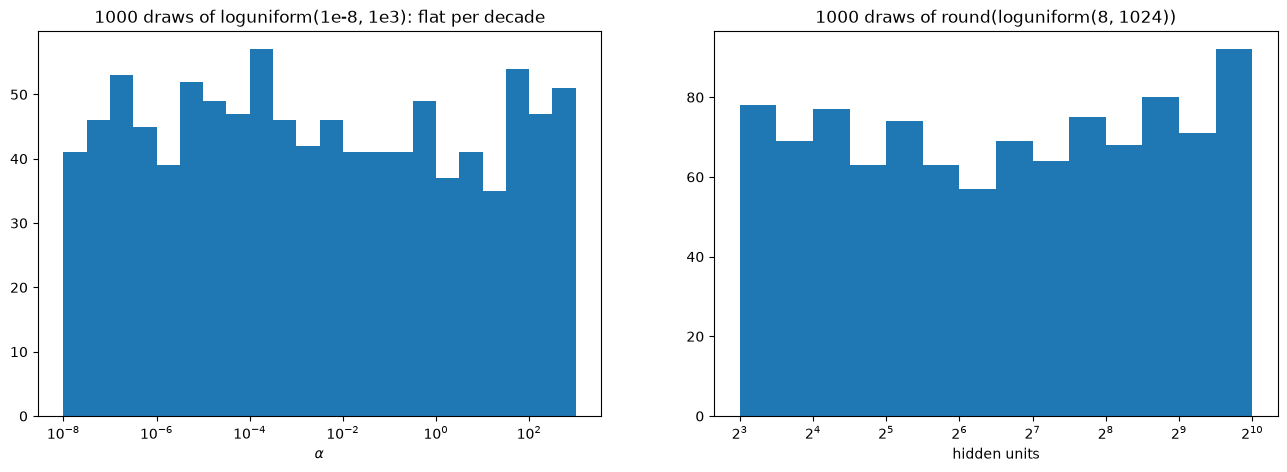

In [4]:
alpha_distribution = loguniform(1e-8, 1e3)
units_distribution = loguniform(8, 1024)
draw_rng = np.random.RandomState(0)
alpha_draws = alpha_distribution.rvs(size=1000, random_state=draw_rng)
unit_draws = np.round(units_distribution.rvs(size=1000, random_state=draw_rng)).astype(int)

fig, (ax_alpha, ax_units) = plt.subplots(1, 2, figsize=(16, 5))
ax_alpha.hist(alpha_draws, bins=np.logspace(-8, 3, 23))
ax_alpha.set_xscale('log')
ax_alpha.set_xlabel(r"$\alpha$")
ax_alpha.set_title("1000 draws of loguniform(1e-8, 1e3): flat per decade")
ax_units.hist(unit_draws, bins=np.logspace(np.log10(8), np.log10(1024), 15))
ax_units.set_xscale('log', base=2)
ax_units.set_xlabel("hidden units")
ax_units.set_title("1000 draws of round(loguniform(8, 1024))")
plt.show()
param_distributions_example = {"linear_regression__alpha": alpha_distribution,
                               "polynomial_features__degree": randint(1, 21)}

### Exercise 5: Where does Bayesian optimization look next?

In [5]:
def f(x):
    """The function being optimized in the chapter."""
    return x * np.sin(x)


ex6_observed_x = np.array([0.0, 1.75, 3.25, 6.5, 10.0])
ex6_gp = GaussianProcessRegressor(kernel=C(3.0) * RBF(1.5), alpha=1e-6, optimizer=None)
ex6_gp.fit(ex6_observed_x[:, np.newaxis], f(ex6_observed_x))
ex6_grid = np.linspace(0, 10, 1001)
ex6_mean, ex6_std = ex6_gp.predict(ex6_grid[:, np.newaxis], return_std=True)
ex6_candidate_x = np.sort([ex6_grid[np.argmax(ex6_mean)], ex6_grid[np.argmax(ex6_mean + 1.96 * ex6_std)],
                           ex6_grid[np.argmax(ex6_mean + 10.0 * ex6_std)], 6.5])

print(" candidate     x     mean   sigma   UCB(k=0)  UCB(k=1.96)  UCB(k=10)")
for letter, cx in zip("ABCD", ex6_candidate_x):
    mu, sd = ex6_gp.predict([[cx]], return_std=True)
    print(f"     {letter}      {cx:5.2f}   {mu[0]:5.2f}   {sd[0]:5.2f}    {mu[0]:6.2f}      {mu[0] + 1.96 * sd[0]:6.2f}     {mu[0] + 10 * sd[0]:6.2f}")
for kappa in [0, 1.96, 10]:
    pick = ex6_candidate_x[np.argmax([ex6_gp.predict([[cx]], return_std=True)[0][0] + kappa * ex6_gp.predict([[cx]], return_std=True)[1][0]
                                      for cx in ex6_candidate_x])]
    print(f"kappa = {kappa:>4}: picks x = {pick:.2f} (candidate {'ABCD'[list(ex6_candidate_x).index(pick)]})")

 candidate     x     mean   sigma   UCB(k=0)  UCB(k=1.96)  UCB(k=10)
     A       1.55    1.77    0.10      1.77        1.97       2.78
     B       5.59    0.85    0.85      0.85        2.51       9.32
     C       6.50    1.40    0.00      1.40        1.40       1.41
     D       7.97   -0.99    1.20     -0.99        1.37      11.05
kappa =    0: picks x = 1.55 (candidate A)
kappa = 1.96: picks x = 5.59 (candidate B)
kappa =   10: picks x = 7.97 (candidate D)


**(a)** UCB with $\kappa = 1.96$ picks **B**, the candidate in the middle of the wide gap between the observations at 3.25 and 6.5: its mean is only moderate but its uncertainty is large, and $\mu + 1.96\sigma$ is the largest of the four. A loses because it sits next to two observations: its mean is the highest, but the band there is so narrow that the bound barely exceeds the mean. D has the widest band of all, but it lies in a region the GP believes is *low* (the mean is negative), so even a wide band does not lift it above B. C is an observed point: its uncertainty is zero and its bound is just the observed value.

**(b)** Greedy ($\kappa = 0$) picks A, the highest mean. Very exploratory ($\kappa = 10$) picks D, the largest uncertainty; the mean hardly matters any more.

**(c)** C, the point that has already been evaluated. Its $\sigma$ is zero and its mean is known, so for every $\kappa$ its bound equals its value, and there is always some unobserved point with a higher bound. Bayesian optimization never re-evaluates a noiseless observation.

### Exercise 6: A Gaussian is a donut

In [6]:
radius = np.linspace(0, 6, 2000)
print(" n   peak of radial density   sqrt(n - 1)")
for n_dim in [1, 2, 3, 5, 10, 20]:
    peak = radius[np.argmax(chi.pdf(radius, df=n_dim))]
    print(f"{n_dim:2d}          {peak:5.2f}               {np.sqrt(max(n_dim - 1, 0)):5.2f}")
for r_limit in [1, 2, 3]:
    print(f"P(r < {r_limit}) in 10 dimensions = {chi.cdf(r_limit, df=10):.4f}")

 n   peak of radial density   sqrt(n - 1)
 1           0.00                0.00
 2           1.00                1.00
 3           1.41                1.41
 5           2.00                2.00
10           3.00                3.00
20           4.36                4.36
P(r < 1) in 10 dimensions = 0.0002
P(r < 2) in 10 dimensions = 0.0527
P(r < 3) in 10 dimensions = 0.4679


**(a)** The peak moves outwards: $r \approx 0$ for $n = 1$, then $1.0$, $1.41$, $2.0$, $3.0$, $4.36$. The radial density is $p(r) \propto r^{n-1} e^{-r^2/2}$ (the chi distribution), and setting its derivative to zero gives the mode at $r = \sqrt{n - 1}$.

::: {.callout-note collapse="true"}
### Derivation of the mode
The mode is where the pdf has zero slope, so we differentiate the pdf and set the slope to zero. We can use the proportional form since constants won't affect the maxima and we can make our lives further easier by noting that logarithms don't affect the minima or maxima of functions. (You will see us use this trick a lot with probability distributions throughout the book.)

So: $\ln(p(r)) \propto \ln(r^{n-1} e^{-r^2/2}) = (n-1)\ln(r) - r^2/2$. Now let's take the derivative w.r.t. $r$ and set it to zero: $\frac{\partial \ln p(r)}{\partial r} = \frac{(n-1)}{r} - r = 0$. Bringing $r$ to one side, we see that $r = \sqrt{n - 1}$.
:::

**(b)** In ten dimensions only about $0.02$ percent of the samples fall inside the unit ball and about $5$ percent inside $r < 2$; the bulk sits between $r \approx 2$ and $r \approx 4$.

**(c)** Both statements are true. The density per unit *volume* is highest at the origin. But the amount of volume at distance $r$, a thin shell, grows like $r^{n-1}$, and in ten dimensions that factor will dominate the slowly decaying $e^{-r^2/2}$ until $r \approx 3$. When N increases, there is simply almost no volume near the origin and so the total likelihood of sampling points at that radius is small compared to the larger shells further out.

**(d)** For distance-based methods: all samples from the same Gaussian sit at nearly the same distance from the mean, and pairwise distances between samples concentrate too, so "close" and "far" lose contrast (See Exercise 9). For sampling: if you draw a random point in a high-dimensional Gaussian it will land on the shell, not near the mean of the Gaussian, so a "typical" sample looks nothing like the "most likely" sample.

### Exercise 7: Nearest and farthest neighbours

d =   1: mean min/max distance ratio = 0.001
d =   2: mean min/max distance ratio = 0.022
d =   5: mean min/max distance ratio = 0.142
d =  10: mean min/max distance ratio = 0.293
d =  20: mean min/max distance ratio = 0.445
d =  50: mean min/max distance ratio = 0.615
d = 100: mean min/max distance ratio = 0.712
d = 500: mean min/max distance ratio = 0.861
d = 1000: mean min/max distance ratio = 0.899


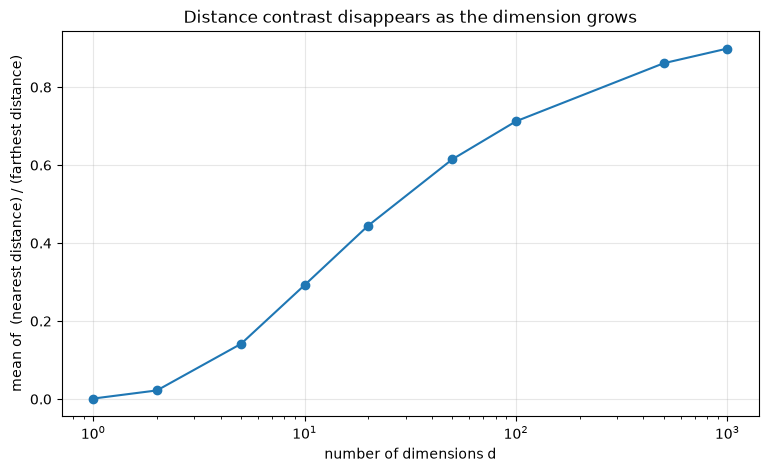

In [7]:
def mean_min_max_ratio(n_dims, n_points=500, seed=0):
    """Mean over points of (distance to nearest other point) / (distance to farthest point) in [0, 1]^n_dims."""
    rng = np.random.default_rng(seed)
    points = rng.uniform(0, 1, size=(n_points, n_dims))
    distances = cdist(points, points)
    np.fill_diagonal(distances, np.inf)          # exclude each point's zero distance to itself
    nearest = distances.min(axis=1)
    np.fill_diagonal(distances, -np.inf)
    farthest = distances.max(axis=1)
    return np.mean(nearest / farthest)


dims = [1, 2, 5, 10, 20, 50, 100, 500, 1000]
ratios = [mean_min_max_ratio(d) for d in dims]
for d, r in zip(dims, ratios):
    print(f"d = {d:3d}: mean min/max distance ratio = {r:.3f}")

plt.figure(figsize=(9, 5))
plt.semilogx(dims, ratios, 'o-')
plt.xlabel("number of dimensions d")
plt.ylabel("mean of  (nearest distance) / (farthest distance)")
plt.title("Distance contrast disappears as the dimension grows")
plt.grid(True, alpha=0.3)
plt.show()

**(a)** The ratio starts near zero in one dimension (the nearest neighbour is very close, the farthest is on the other side of the interval) and climbs steadily towards 1: at $d = 1000$ the nearest and the farthest neighbour are within a few tens of percent of the same distance. Every point is roughly equally far from every other point.

**(b)** $k$-nearest-neighbour methods rely on the nearest neighbours being *meaningfully* nearer than the rest. Increasing the dimensions doesn't change which point is closest to you, but the relative scale or distance compared to further neighbors becomes harder to distinguish, if you are using a method that weighs neighbors in proportion to their distance. In a sense, in high dimensions, everyone looks almost equally far away.

**(c)** A grid with $m$ values per hyperparameter needs $m^d$ evaluations, so it becomes impossible after a handful of dimensions. Random search does not blow up in the same way, but the volume-ratio plot and this one together say why it also gets harder: in high dimensions a random sample is almost always far from any particular good region, and the "corners" of the search box contain almost all of the volume. This is the motivation for model-based methods such as Bayesian optimization, which attempt to target their samples into regions that would be help the model, although as we can see above when every point looks far away, Bayesian optimization will spend a lot of samples trying to cover an exponentially larger space, and thus often breaks down as well in high dimensions.